In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.linalg as la
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from torch.utils.data import TensorDataset, DataLoader

# ----------------------------
# Configuration
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Problem settings
NUM_CLASSES  = 10
FEATURES     = 28 * 28

Device: cuda


In [48]:
# ----------------------------
# Data
# ----------------------------
def load_mnist():
    # MNIST dataset
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
        # transforms.Lambda(torch.flatten)
    ])
    train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
    test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
    return train_dataset, test_dataset

In [49]:
# ----------------------------
# Model definition
# ----------------------------
class ActNorm(nn.Module):
    """
    Activation Normalization for 4D tensors (images).
    Initializes scale and bias parameters based on the first batch of data.
    """
    def __init__(self, num_channels):
        super().__init__()
        # DO NOT hardcode the device here. Let .to(device) handle it.
        self.scale = nn.Parameter(torch.ones(1, num_channels, 1, 1))
        self.bias = nn.Parameter(torch.zeros(1, num_channels, 1, 1))
        self.register_buffer("initialized", torch.tensor(0, dtype=torch.uint8))

    def forward(self, x):
        # x shape: [B, C, H, W]
        if not self.initialized:
            with torch.no_grad():
                # Calculate mean and stddev over batch and spatial dimensions
                mean = x.mean(dim=[0, 2, 3], keepdim=True)
                std = x.std(dim=[0, 2, 3], keepdim=True)
                self.scale.data.copy_(1.0 / (std + 1e-6))
                self.bias.data.copy_(-mean)
                self.initialized.fill_(1)

        y = self.scale * x + self.bias

        # The log-determinant needs to be scaled by the spatial dimensions
        _, _, h, w = x.size()
        log_det = torch.sum(torch.log(torch.abs(self.scale))) * h * w
        return y, log_det


class Squeeze(nn.Module):
    """
    Squeeze operation that trades spatial dimensions for channel dimensions.
    (B, C, H, W) -> (B, 4*C, H/2, W/2)
    """
    def __init__(self):
        super().__init__()

    def forward(self, x):
        b, c, h, w = x.size()
        x = x.view(b, c, h // 2, 2, w // 2, 2)
        x = x.permute(0, 1, 3, 5, 2, 4).contiguous()
        x = x.view(b, c * 4, h // 2, w // 2)
        return x, 0 # No change to log_det


class CNNCouplingLayer(nn.Module):
    """
    Affine Coupling Layer using a CNN for the coupling function.
    """
    def __init__(self, in_channels, hidden_channels=256):
        super().__init__()
        self.in_channels = in_channels
        self.split_size = in_channels // 2

        # A shallow ResNet-like CNN for the coupling function
        self.coupling_net = nn.Sequential(
            nn.Conv2d(self.split_size, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=1),
            nn.ReLU(),
            # Output 2x channels for s and t
            nn.Conv2d(hidden_channels, self.in_channels, kernel_size=3, padding=1)
        )

        # Initialize last layer to zero for stability
        self.coupling_net[-1].weight.data.zero_()
        self.coupling_net[-1].bias.data.zero_()

    def forward(self, x):
        x_a, x_b = x.split(self.split_size, dim=1)

        s_and_t = self.coupling_net(x_a)
        log_s, t = s_and_t.split(self.split_size, dim=1)
        s = torch.exp(torch.tanh(log_s))

        y_b = x_b * s + t
        y = torch.cat([x_a, y_b], dim=1)

        # Sum log_det over all dimensions except batch
        log_det = torch.sum(torch.log(s), dim=[1, 2, 3])
        return y, log_det


class Invertible1x1Conv(nn.Module):
    """
    Invertible 1x1 Convolution using LU decomposition for initialization.
    Registers an 'initialized' buffer to prevent re-initialization after loading.
    """
    def __init__(self, num_channels):
        super().__init__()
        self.conv = nn.Conv2d(num_channels, num_channels, kernel_size=1, bias=False)

        # Initialize with a random orthogonal matrix for good conditioning
        W = torch.qr(torch.randn(num_channels, num_channels))[0]
        self.conv.weight.data.copy_(W.view(num_channels, num_channels, 1, 1))

        # This buffer WILL be saved in the state_dict, solving the problem.
        self.register_buffer("initialized", torch.tensor(1, dtype=torch.uint8))

    def forward(self, x):
        # The weight is already initialized, so we just apply the convolution.
        y = self.conv(x)

        # Calculate log-determinant
        _, _, h, w = x.size()
        log_det = torch.slogdet(self.conv.weight.squeeze())[1] * h * w

        return y, log_det


class DNFNetwork(nn.Module):
    """
    Deep Neural Flow (DNF) Network using CNN Coupling Layers for images.
    """
    def __init__(self, in_channels: int, num_layers: int):
        super(DNFNetwork, self).__init__()

        self.squeeze = Squeeze()
        # After squeeze, channels = 1*4=4, H/W = 28/2=14
        current_channels = in_channels * 4

        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            self.layers.append(ActNorm(current_channels))
            # Use our new invertible 1x1 conv module
            self.layers.append(Invertible1x1Conv(current_channels))
            self.layers.append(CNNCouplingLayer(current_channels))

    def forward(self, x):
        # Reshape from flattened to image format
        if len(x.shape) == 2:
            x = x.view(-1, 1, 28, 28)

        total_log_det = torch.zeros(x.shape[0], device=x.device)

        x, log_det = self.squeeze(x)
        total_log_det += log_det

        # The forward pass is now clean, with no conditional initialization logic.
        for layer in self.layers:
            x, log_det = layer(x)
            total_log_det += log_det

        # Flatten the output for the loss function
        return x.flatten(start_dim=1), total_log_det

In [50]:
# ----------------------------
# Loss definition
# ----------------------------
# Define the target latent distributions (F-dimensional Gaussians).
# We will separate them along the first dimension for simplicity.
means = torch.zeros(NUM_CLASSES, FEATURES, device=device)
distance = 4.0  # A reasonable distance to separate the means
for i in range(NUM_CLASSES):
    means[i, i] = distance

# We assume a standard deviation of 1 for all dimensions (identity covariance).
# This creates a list of MultivariateNormal distribution objects.
# These represent our fixed target distributions φ_c.
target_distributions = [
    torch.distributions.MultivariateNormal(
        loc=means[i],
        covariance_matrix=torch.eye(FEATURES, device=device)
    )
    for i in range(NUM_CLASSES)
]

def dnf_loss(z, total_log_det, y_true):
    """
    Computes the DNF loss based on the cross-entropy of the class likelihoods.

    Args:
        z (torch.Tensor): The output from the DNF network (latent space representation).
                          Shape: [batch_size, features]
        total_log_det (torch.Tensor): The total log-determinant from the DNF network.
                                      Shape: [batch_size]
        y_true (torch.Tensor): The true class labels.
                               Shape: [batch_size]

    Returns:
        torch.Tensor: The final loss value (scalar).
    """
    # Calculate log φ_c(z) for all classes.
    # This evaluates the log probability of the latent points `z` under each target distribution.
    log_phi_c = torch.stack(
        [dist.log_prob(z) for dist in target_distributions],
        dim=1
    ) # Shape: [batch_size, num_classes]

    # Calculate the log-likelihood for each class:
    # log π'_c(x) = log φ_c(z) + log|det J|
    # We need to add the log_det term to each class's log_phi.
    # total_log_det has shape [batch_size], we unsqueeze to make it [batch_size, 1]
    # for broadcasting across the class dimension.
    logits = log_phi_c
    logits += total_log_det.unsqueeze(1)

    # Use standard cross-entropy loss on the computed logits.
    # This loss function implicitly performs the softmax and computes the negative log-likelihood.
    loss = nn.functional.cross_entropy(logits, y_true)

    return loss

In [51]:
# ----------------------------
# Training Setup
# ----------------------------

# Training Hyperparameters
# NUM_LAYERS   = 5         # Number of dense + activation layers
# LR = 1e-2
# EPOCHS = 100
# BATCH_SIZE = 256
# LAM = 1e-2
# WEIGHT_DECAY = 1e-4 # Using AdamW's weight decay for regularization

NUM_LAYERS = 6         # Number of dense + activation layers
LR = 1e-3
EPOCHS = 30
BATCH_SIZE = 256
LAM = 1e-5
WEIGHT_DECAY = 1e-4 # Using AdamW's weight decay for regularization

# Instantiate the model and move it to the device
model = DNFNetwork(in_channels=1, num_layers=NUM_LAYERS).to(device)

# Use AdamW optimizer which is good for regularization
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Create TensorDatasets and DataLoadersc
train_dataset, test_dataset = load_mnist()
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [57]:
# ----------------------------
# Training Loop
# ----------------------------
print("Starting training...")
train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        # Forward pass
        z, total_log_det = model(x_batch)

        # Calculate loss
        loss = dnf_loss(z, total_log_det, y_batch)

        # Regularization term
        log_det_regularization = (total_log_det ** 2).mean()
        loss += LAM * log_det_regularization

        # Backward pass and optimization
        loss.backward()
        # Add gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_train_loss += loss.item()

    # --- Evaluation ---
    model.eval()
    total_test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            z, total_log_det = model(x_batch)

            # Calculate test loss
            loss = dnf_loss(z, total_log_det, y_batch) + LAM * (total_log_det ** 2).mean()
            total_test_loss += loss.item()

            # Calculate accuracy
            log_phi_c = torch.stack([dist.log_prob(z) for dist in target_distributions], dim=1)
            logits = log_phi_c + total_log_det.unsqueeze(1)
            _, predicted = torch.max(logits.data, 1)

            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_test_loss = total_test_loss / len(test_loader)
    accuracy = 100 * correct / total

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)
    test_accuracies.append(accuracy)

    last_log_det_mean = total_log_det.mean().item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Test Acc: {accuracy:.2f}% | LogDet: {last_log_det_mean:.2f}")
    scheduler.step()


print("Finished training.")

Starting training...
Epoch [1/30] | Train Loss: 0.0095 | Test Acc: 98.10% | LogDet: 0.47


KeyboardInterrupt: 

In [62]:
# --------------------------------------------
# Saving the Base Model Checkpoint
# --------------------------------------------
BASE_CHECKPOINT_PATH = "dnf_mnist_base_checkpoint.pth"
print(f"Saving checkpoint to {BASE_CHECKPOINT_PATH}...")

# Save a dictionary containing the model state and the optimizer state.
# This is the robust way to save your progress.
torch.save({
    'epoch': EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, BASE_CHECKPOINT_PATH)

print("Checkpoint saved successfully.")

Saving checkpoint to dnf_mnist_base_checkpoint.pth...
Checkpoint saved successfully.


In [94]:
# ---------------------------------------------------
# Load Checkpoint
# ---------------------------------------------------
BASE_CHECKPOINT_PATH = "dnf_mnist_base_checkpoint.pth"

# --- 1. Instantiate a new model and optimizer ---
# This simulates loading the model in a new script or for verification.
model = DNFNetwork(in_channels=1, num_layers=NUM_LAYERS).to(device)
optimizer = optim.AdamW(model.parameters())

# --- 2. Load the checkpoint file ---
print(f"Loading checkpoint from {BASE_CHECKPOINT_PATH}...")
checkpoint = torch.load(BASE_CHECKPOINT_PATH)

# --- 3. Load the states into the new instances ---
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# --- 4. Set the model to evaluation mode ---
# This is CRUCIAL to prevent layers like ActNorm from re-initializing
# and to disable dropout if you were using it.
model.eval()

print("Model loaded successfully.")

# You can now run evaluation on `verification_model` to confirm its performance
# is identical to the original `model` at the end of training.

# IMPORTANT: For the next step (fine-tuning), you will continue to use the
# original `model` and `optimizer` objects that are already in memory.

Loading checkpoint from dnf_mnist_base_checkpoint.pth...
Model loaded successfully.



Classification Report (Base Model):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.99      0.98      0.98      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



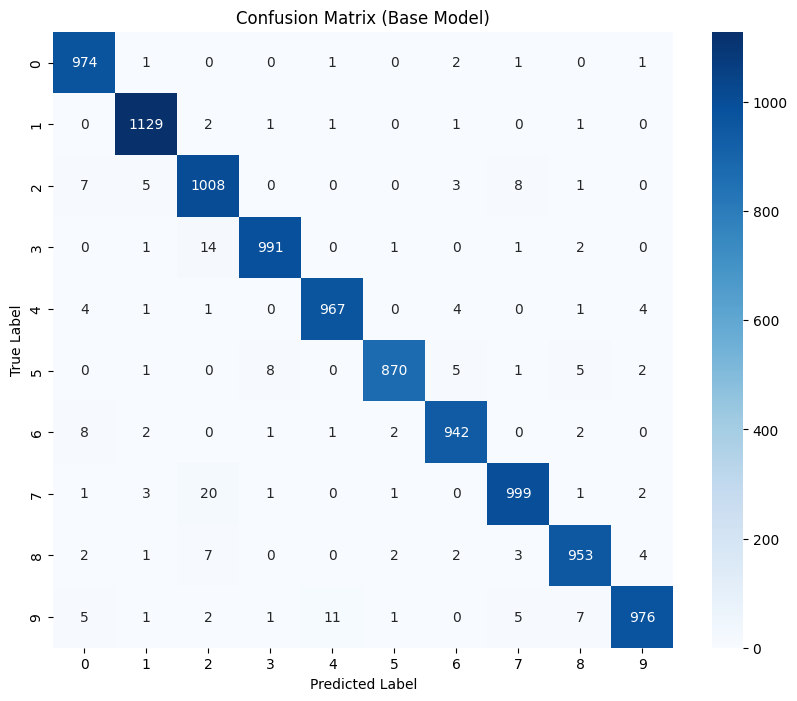

In [95]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# --- 1. Load the base model ---
# Instantiate a new model to ensure we're loading into a fresh state
base_model = model

# --- 2. Get predictions for the test set using the base model ---
with torch.no_grad():
    # Recreate the test dataloader to get the full dataset
    _, test_dataset_full = load_mnist()
    X_test_tensor = torch.stack([item[0] for item in test_dataset_full]).to(device)
    y_test = np.array([item[1] for item in test_dataset_full])

    # Define target names for MNIST
    mnist_target_names = [str(i) for i in range(10)]

    # Use the ORIGINAL, FIXED target_distributions
    z, total_log_det = base_model(X_test_tensor)
    log_phi_c = torch.stack([dist.log_prob(z) for dist in target_distributions], dim=1)
    logits = log_phi_c + total_log_det.unsqueeze(1)
    _, y_pred = torch.max(logits.data, 1)
    y_pred = y_pred.cpu().numpy()

# --- 3. Print the classification report and confusion matrix ---
print("\nClassification Report (Base Model):")
print(classification_report(y_test, y_pred, target_names=mnist_target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=mnist_target_names, yticklabels=mnist_target_names)
plt.title('Confusion Matrix (Base Model)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [96]:
# -------------------------------------------------
# Stage 2: Generative Fine-Tuning for Calibration
# -------------------------------------------------

# --- 1. Define Trainable Latent Parameters ---
# We initialize the means at their original fixed locations.
# By wrapping them in nn.Parameter, they become part of the model's trainable parameters.
initial_means = torch.zeros(NUM_CLASSES, FEATURES, device=device)
distance = 4.0
for i in range(NUM_CLASSES):
    initial_means[i, i] = distance
trainable_means = nn.Parameter(initial_means)

# Define trainable log variances, initialized to zero (i.e., variance of 1).
# We train the log of the variance for numerical stability and to ensure positivity.
initial_log_vars = torch.zeros(NUM_CLASSES, FEATURES, device=device)
trainable_log_vars = nn.Parameter(initial_log_vars)


# --- 2. Define Dynamic Loss Functions ---
# Helper to create distributions from the current state of the trainable parameters.
def get_target_distributions(means_param, log_vars_param):
    # The covariance matrix is now diagonal, with elements exp(log_vars)
    return [
        torch.distributions.MultivariateNormal(
            loc=means_param[i],
            covariance_matrix=torch.diag(torch.exp(log_vars_param[i]))
        ) for i in range(NUM_CLASSES)
    ]

# A version of the loss function that accepts dynamic distributions.
def dnf_loss_dynamic(z, total_log_det, y_true, target_dists):
    log_phi_c = torch.stack([dist.log_prob(z) for dist in target_dists], dim=1)
    logits = log_phi_c + total_log_det.unsqueeze(1)
    loss = nn.functional.cross_entropy(logits, y_true)
    return loss, logits

# The generative loss component: negative log-likelihood of data given the true class.
def generative_loss_fn(z, total_log_det, y_true, target_dists):
    # Get log_prob of z under the target distribution for the TRUE class y_true
    log_phi_y_true = target_dists[0].log_prob(z).new_empty(z.shape[0])
    for i in range(NUM_CLASSES):
        mask = (y_true == i)
        if mask.any():
            log_phi_y_true[mask] = target_dists[i].log_prob(z[mask])

    # log p(x|y) = log φ_y(z) + log|det J|
    log_likelihood_true_class = log_phi_y_true + total_log_det
    # We want to MAXIMIZE log-likelihood, so we MINIMIZE its negative.
    return -log_likelihood_true_class.mean()


# --- 3. Fine-Tuning Training Loop ---
print("Starting generative fine-tuning...")

# Hyperparameters for fine-tuning
FT_EPOCHS = 30
FT_LR_MODEL = 1e-4      # LR for the main network
FT_LR_MEANS = 1e-4      # LR for the means
FT_LR_VARS = 1e-5       # LR for the variances
ALPHA = 1e-2            # Weight for the generative loss
BETA = 1e-1             # Regularization strength for the variances
LAM = 1e-3              # Regularization strength for the log det

# Add the trainable parameters to the optimizer with their own learning rates
optimizer.add_param_group({'params': [trainable_means], 'lr': FT_LR_MEANS})
optimizer.add_param_group({'params': [trainable_log_vars], 'lr': FT_LR_VARS})

# Update the learning rate for the original model parameters
for param_group in optimizer.param_groups:
    if 'lr' not in param_group: # The original param group has no explicit LR set yet
        param_group['lr'] = FT_LR_MODEL

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(FT_EPOCHS):
    model.train()
    total_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        # Get the current dynamic target distributions using both means and vars
        target_dists = get_target_distributions(trainable_means, trainable_log_vars)

        # Forward pass
        z, total_log_det = model(x_batch)

        # Calculate discriminative loss
        disc_loss, _ = dnf_loss_dynamic(z, total_log_det, y_batch, target_dists)

        # Calculate generative loss
        gen_loss = generative_loss_fn(z, total_log_det, y_batch, target_dists)

        # Combine into a hybrid loss
        loss = disc_loss + ALPHA * gen_loss

        # Regularization
        # 1. Log-determinant regularization
        loss += LAM * (total_log_det ** 2).mean()
        # 2. Variance regularization: Penalize log_vars for deviating from zero
        loss += BETA * (trainable_log_vars ** 2).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_([trainable_means], max_norm=1.0)
        torch.nn.utils.clip_grad_norm_([trainable_log_vars], max_norm=1.0)
        optimizer.step()

        total_train_loss += loss.item()

    # --- Evaluation ---
    model.eval()
    total_test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        # Get dynamic distributions for evaluation
        eval_target_dists = get_target_distributions(trainable_means, trainable_log_vars)

        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            z, total_log_det = model(x_batch)

            # Calculate test loss
            loss, logits = dnf_loss_dynamic(z, total_log_det, y_batch, eval_target_dists)
            loss += LAM * (total_log_det ** 2).mean()
            loss += BETA * (trainable_log_vars ** 2).mean()
            total_test_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(logits.data, 1)

            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_test_loss = total_test_loss / len(test_loader)
    accuracy = 100 * correct / total

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)
    test_accuracies.append(accuracy)

    last_log_det_mean = total_log_det.mean().item()

    print(f"Epoch [{epoch+1}/{FT_EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Test Acc: {accuracy:.2f}% | LogDet: {last_log_det_mean:.2f}")

print("Finished fine-tuning.")

Starting generative fine-tuning...
Epoch [1/30] | Train Loss: 21004.1289 | Test Acc: 86.82% | LogDet: 9.00
Epoch [2/30] | Train Loss: 8.4299 | Test Acc: 93.56% | LogDet: -4.42
Epoch [3/30] | Train Loss: 8.0182 | Test Acc: 95.08% | LogDet: 15.49
Epoch [4/30] | Train Loss: 7.8412 | Test Acc: 95.91% | LogDet: -0.01
Epoch [5/30] | Train Loss: 7.7380 | Test Acc: 96.55% | LogDet: 2.93
Epoch [6/30] | Train Loss: 7.6669 | Test Acc: 96.90% | LogDet: 12.45
Epoch [7/30] | Train Loss: 7.6158 | Test Acc: 97.18% | LogDet: -1.99
Epoch [8/30] | Train Loss: 7.5747 | Test Acc: 97.36% | LogDet: 9.58
Epoch [9/30] | Train Loss: 7.5417 | Test Acc: 97.37% | LogDet: 7.29
Epoch [10/30] | Train Loss: 7.5131 | Test Acc: 97.47% | LogDet: -2.20
Epoch [11/30] | Train Loss: 7.4892 | Test Acc: 97.66% | LogDet: 12.99
Epoch [12/30] | Train Loss: 7.4681 | Test Acc: 97.71% | LogDet: -0.21
Epoch [13/30] | Train Loss: 7.4483 | Test Acc: 97.72% | LogDet: 3.06
Epoch [14/30] | Train Loss: 7.4320 | Test Acc: 97.96% | LogDet: 1

In [100]:
# --------------------------------------------
# Saving the Fine-Tuned Model Checkpoint
# --------------------------------------------

FT_CHECKPOINT_PATH = "dnf_mnist_finetuned_checkpoint.pth"
print(f"Saving fine-tuned checkpoint to {FT_CHECKPOINT_PATH}...")

# Save a dictionary containing the model state, the optimizer state,
# and the final positions of the trainable means and variances.
torch.save({
    'epoch': FT_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'trainable_means': trainable_means,
    'trainable_log_vars': trainable_log_vars,
}, FT_CHECKPOINT_PATH)

print("Fine-tuned checkpoint saved successfully.")

Saving fine-tuned checkpoint to dnf_mnist_finetuned_checkpoint.pth...
Fine-tuned checkpoint saved successfully.


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.97      0.98      1010
           4       0.99      0.98      0.99       982
           5       0.98      0.98      0.98       892
           6       0.99      0.97      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



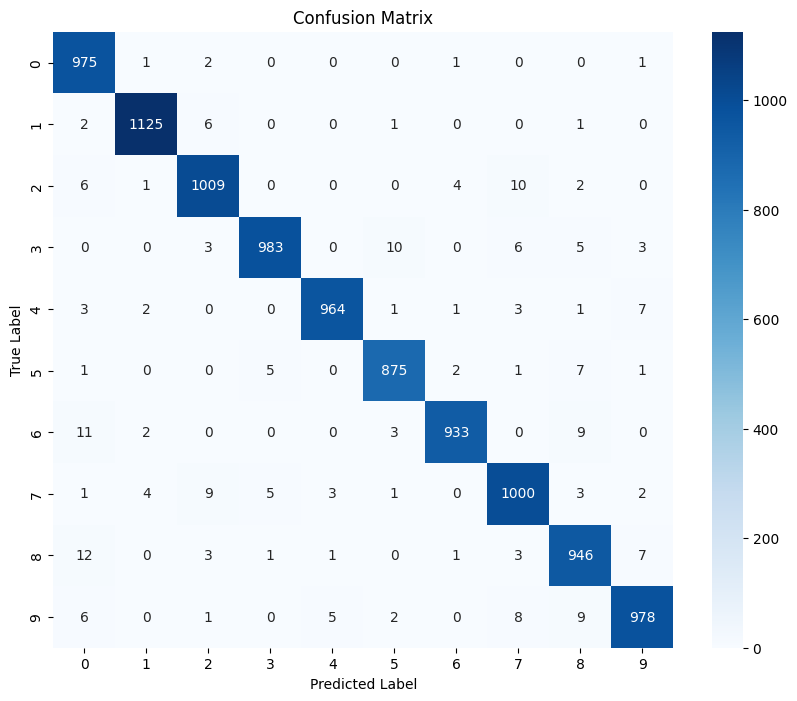

In [99]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get model predictions for the test set
model.eval()
with torch.no_grad():
    # Recreate the test dataloader to get the full dataset
    _, test_dataset_full = load_mnist()
    X_test_tensor = torch.stack([item[0] for item in test_dataset_full]).to(device)
    y_test = np.array([item[1] for item in test_dataset_full])

    # Define target names for MNIST
    mnist_target_names = [str(i) for i in range(10)]

    # Get the final target distributions
    final_target_dists = get_target_distributions(trainable_means, trainable_log_vars)

    z, total_log_det = model(X_test_tensor)
    log_phi_c = torch.stack([dist.log_prob(z) for dist in final_target_dists], dim=1)
    logits = log_phi_c + total_log_det.unsqueeze(1)
    _, y_pred = torch.max(logits.data, 1)
    y_pred = y_pred.cpu().numpy()

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=mnist_target_names))

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=mnist_target_names, yticklabels=mnist_target_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Expected Calibration Error (ECE): 0.0035

Calibration Analysis Table:
Bin Confidence Range Avg Confidence Accuracy    Gap  Samples
  1      0.00 - 0.07          0.000    0.000 +0.000        0
  2      0.07 - 0.13          0.000    0.000 +0.000        0
  3      0.13 - 0.20          0.000    0.000 +0.000        0
  4      0.20 - 0.27          0.000    0.000 +0.000        0
  5      0.27 - 0.33          0.303    0.500 -0.197        4
  6      0.33 - 0.40          0.373    0.538 -0.166       13
  7      0.40 - 0.47          0.443    0.310 +0.133       29
  8      0.47 - 0.53          0.506    0.450 +0.056       40
  9      0.53 - 0.60          0.565    0.600 -0.035       40
 10      0.60 - 0.67          0.634    0.618 +0.016       55
 11      0.67 - 0.73          0.697    0.650 +0.047       60
 12      0.73 - 0.80          0.768    0.741 +0.027       81
 13      0.80 - 0.87          0.835    0.791 +0.044      115
 14      0.87 - 0.93          0.903    0.874 +0.029      190
 15      0.93 -

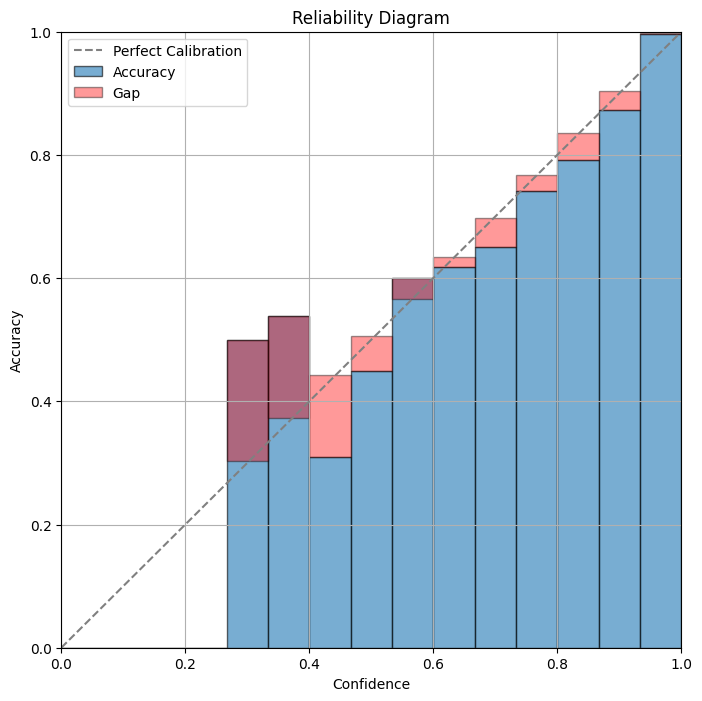

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# Calibration Analysis (ECE)
# ----------------------------

# 1. Get model probabilities for the test set
model.eval()
with torch.no_grad():
    # Use the same full test set tensors from the previous cell
    final_target_dists = get_target_distributions(trainable_means, trainable_log_vars)

    z, total_log_det = model(X_test_tensor)
    log_phi_c = torch.stack([dist.log_prob(z) for dist in final_target_dists], dim=1)
    logits = log_phi_c + total_log_det.unsqueeze(1)

    # Apply softmax to logits to get probabilities
    probabilities = torch.softmax(logits, dim=1)

    # Get the confidence (max probability) and predicted class for each sample
    confidences, predictions = torch.max(probabilities, 1)

# Convert to numpy for calculation
confidences = confidences.cpu().numpy()
predictions = predictions.cpu().numpy()
true_labels = y_test # y_test is already a numpy array from the previous cell

# 2. Calculate ECE
def calculate_ece(confidences, predictions, true_labels, n_bins=15):
    """Calculates the Expected Calibration Error (ECE)."""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    ece = 0.0
    accuracies_in_bin = []
    avg_conf_in_bin = []
    samples_in_bin_list = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        num_samples = np.sum(in_bin)
        samples_in_bin_list.append(num_samples)

        if prop_in_bin > 0:
            accuracy = np.mean(predictions[in_bin] == true_labels[in_bin])
            avg_confidence = np.mean(confidences[in_bin])
            ece += np.abs(accuracy - avg_confidence) * prop_in_bin

            accuracies_in_bin.append(accuracy)
            avg_conf_in_bin.append(avg_confidence)
        else:
            accuracies_in_bin.append(0)
            avg_conf_in_bin.append(0)

    return ece, accuracies_in_bin, avg_conf_in_bin, samples_in_bin_list, bin_boundaries

ece, accuracies, avg_confs, samples_in_bin, bin_bounds = calculate_ece(confidences, predictions, true_labels)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

# 4. Create and display calibration table
print("\nCalibration Analysis Table:")
cal_data = {
    "Bin": [f"{i+1}" for i in range(len(accuracies))],
    "Confidence Range": [f"{bin_bounds[i]:.2f} - {bin_bounds[i+1]:.2f}" for i in range(len(accuracies))],
    "Avg Confidence": avg_confs,
    "Accuracy": accuracies,
    "Gap": [conf - acc for conf, acc in zip(avg_confs, accuracies)],
    "Samples": samples_in_bin
}
df_cal = pd.DataFrame(cal_data)
df_cal["Avg Confidence"] = df_cal["Avg Confidence"].map('{:.3f}'.format)
df_cal["Accuracy"] = df_cal["Accuracy"].map('{:.3f}'.format)
df_cal["Gap"] = df_cal["Gap"].map('{:+.3f}'.format)

# Display the DataFrame without the index
print(df_cal.to_string(index=False))


# 3. Plot Reliability Diagram
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

# Create a bar plot for the accuracies in each bin
n_bins = len(accuracies)
bin_centers = np.linspace(0, 1, n_bins * 2 + 1)[1::2]
bin_width = 1.0 / n_bins

# Plot bars for accuracy
plt.bar(bin_centers, accuracies, width=bin_width, edgecolor='black', alpha=0.6, label='Accuracy')
# Plot bars for confidence (gap)
plt.bar(bin_centers, [c-a for c,a in zip(avg_confs, accuracies)], bottom=accuracies, width=bin_width, edgecolor='black', alpha=0.4, color='red', label='Gap')


plt.title('Reliability Diagram')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

In [98]:
from sklearn.metrics import log_loss, brier_score_loss

# --------------------------------------------
# Calculate NLL and Brier Score
# --------------------------------------------

# Ensure the model is in evaluation mode
model.eval()

# Get model probabilities for the test set
# Use the X_test_tensor which contains the entire test dataset
with torch.no_grad():
    # We already have z, total_log_det, probabilities, and y_test from the previous cells
    # but we can recalculate for clarity and completeness.

    final_target_dists = get_target_distributions(trainable_means, trainable_log_vars)

    z, total_log_det = model(X_test_tensor)
    log_phi_c = torch.stack([dist.log_prob(z) for dist in final_target_dists], dim=1)
    logits = log_phi_c + total_log_det.unsqueeze(1)

    # Apply softmax to logits to get probabilities
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()

# The true labels are in y_test (numpy array) from the classification report cell

# Calculate Negative Log-Likelihood (NLL)
# log_loss expects true labels (0 to n_classes-1) and predicted probabilities
nll = log_loss(y_test, probabilities)
print(f"\nNegative Log-Likelihood (NLL): {nll:.4f}")

# Calculate Brier Score
# We can calculate the multi-class Brier score as the mean squared difference between
# the predicted probability vector and the one-hot encoded true label vector.

# One-hot encode true labels
y_true_one_hot = np.eye(NUM_CLASSES)[y_test]

# Calculate multi-class Brier Score
brier_score = np.mean(np.sum((probabilities - y_true_one_hot)**2, axis=1))
print(f"Multi-class Brier Score: {brier_score:.4f}")


Negative Log-Likelihood (NLL): 0.0659
Multi-class Brier Score: 0.0317
